In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import MeanAbsolutePercentageError

import os
import glob
from pathlib import Path
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:
cols = ["bedrooms", "bathrooms", "areas", "zipcode", "price"]
df = pd.read_csv("/mnt/e/Deep Learning/data/Houses Dataset/HousesInfo.txt", sep=" ", header=None, names=cols)
df

,bedrooms,bathrooms,areas,zipcode,price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226
...,...,...,...,...,...
530,5,2.0,2066,94531,399900
531,4,3.5,9536,94531,460000
532,3,2.0,2014,94531,407000
533,4,3.0,2312,94531,419000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   bedrooms   535 non-null    int64  
 1   bathrooms  535 non-null    float64
 2   areas      535 non-null    int64  
 3   zipcode    535 non-null    int64  
 4   price      535 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 21.0 KB


In [21]:
list_most_zipcode = list(df["zipcode"].value_counts()[df["zipcode"].value_counts().values > 25].index.to_numpy().tolist())
list_most_zipcode

[92276, 93510, 93446, 92880, 94501, 91901, 92677]

In [26]:
df = df[df['zipcode'].isin(list_most_zipcode)]
df

,bedrooms,bathrooms,areas,zipcode,price
30,5,3.0,2520,93446,789000
32,3,2.0,1802,93446,365000
39,3,3.0,2146,93446,455000
80,4,2.5,2464,91901,599000
81,2,2.0,1845,91901,529800
...,...,...,...,...,...
499,4,4.0,3000,93446,1495000
500,3,2.0,2330,93446,599900
501,3,2.5,1339,93446,344900
502,3,2.0,1472,93446,309995


In [ ]:
idxs = df.index.values + 1

for idx in idxs:
    base_dir = Path("/mnt/e/Deep Learning/data/Houses Dataset")
    out_dir = os.path.join(base_dir, "concats")
    os.makedirs(out_dir, exist_ok=True)
    
    image = np.zeros(shape=(64, 64, 3), dtype=np.uint8)

    list_files = sorted([file.name for file in list(base_dir.glob(f"{idx}_*"))])

    for i, name in enumerate(list_files):
        path_image = os.path.join(base_dir, name)

        img = cv2.imread(path_image)
        img = cv2.resize(img, dsize=(32, 32), interpolation=cv2.INTER_AREA)
        
        if i == 0:
            image[:32, :32, :] = img
        elif i == 1:
            image[:32, 32: , :] = img
        elif i == 2:
            image[32:, :32, :] = img
        else:
            image[32:, 32:, :] = img
        
    cv2.imwrite(os.path.join(out_dir, f"{idx}_concat.jpg"), image)
    

Text(0.5, 1.0, 'Image 31')

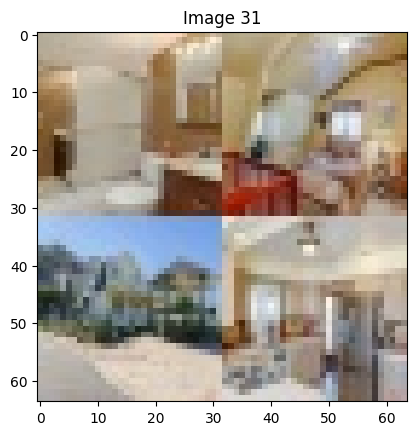

In [48]:
path_31 = "/mnt/e/Deep Learning/data/Houses Dataset/concats/31_concat.jpg"
image_31 = cv2.imread(path_31)

plt.imshow(image_31[..., ::-1]); plt.title("Image 31")

In [88]:
image_name_list = os.listdir("/mnt/e/Deep Learning/data/Houses Dataset/concats")
key_sort = sorted([int(name.split("_")[0]) for name in image_name_list])

def extract_first_number(path):
    return int(path.split("_")[0].split("/")[-1])

image_path_list = sorted([os.path.join(out_dir, image_name) for image_name in image_name_list], key=extract_first_number)

In [89]:
images = np.array([cv2.imread(path) for path in image_path_list])
print(images.shape)

(362, 64, 64, 3)


In [90]:
train_df, val_df, train_images, val_images = train_test_split(df, images, test_size=0.2, random_state=42)

print(f"Shape of train dataframe: {train_df.shape}")
print(f"Shape of train images: {train_images.shape}")

print(f"Shape of val dataframe: {val_df.shape}")
print(f"Shape of val images: {val_images.shape}")

Shape of train dataframe: (289, 5)
Shape of train images: (289, 64, 64, 3)
Shape of val dataframe: (73, 5)
Shape of val images: (73, 64, 64, 3)


In [91]:
train_y = train_df['price']
val_y = val_df['price']

max = df['price'].max()

train_y /= max
val_y /= max

train_df = train_df.drop(columns=["price"])
val_df = val_df.drop(columns=['price'])

In [92]:
train_df

,bedrooms,bathrooms,areas,zipcode
351,2,2.0,1512,92276
479,2,2.0,1190,93446
498,3,2.5,1500,93446
185,6,4.0,3492,94501
194,2,1.0,805,94501
...,...,...,...,...
181,3,2.5,2185,94501
228,5,5.0,3701,92880
412,2,2.0,1344,92276
490,3,2.0,2108,93446


Text(0.5, 1.0, 'Image number 352')

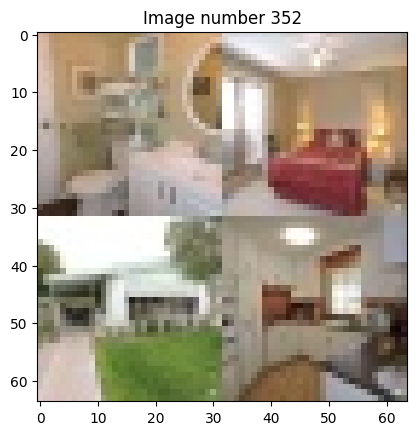

In [93]:
plt.imshow(train_images[0][..., ::-1]); plt.title("Image number 352")

___

In [102]:
height, width, num_channels = (64, 64, 3)

input = keras.layers.Input(shape=(height, width, num_channels))

x = keras.layers.Conv2D(16, (3, 3), padding='same')(input)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPool2D((2, 2))(x)

x = keras.layers.Conv2D(32, (3, 3), padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPool2D((2, 2))(x)

x = keras.layers.Conv2D(64, (3, 3), padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPool2D((2, 2))(x)

x = keras.layers.Flatten()(x)

x = keras.layers.Dense(16)(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(4)(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

output = keras.layers.Dense(1, activation='linear')(x)

model = Model(input, output)

In [103]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │        65,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4)              │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 89,737 (350.54 KB)

 Trainable params: 89,473 (349.50 KB)

 Non-trainable params: 264 (1.03 KB)

In [104]:
model.compile(optimizer=Adam(learning_rate=0.01),
              loss=MeanAbsolutePercentageError)

In [105]:
model.fit(train_images, train_y, validation_data=(val_images, val_y), epochs=50, batch_size=32)

Epoch 1/50


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1407.3606 - val_loss: 139741.1250
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 1014.4623 - val_loss: 151034.4844
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 711.4614 - val_loss: 61310.6250
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 453.3960 - val_loss: 22277.2812
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 324.6390 - val_loss: 12607.2744
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 236.0300 - val_loss: 9400.1621
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 208.1709 - val_loss: 7168.3159
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 159.0832 - val_loss: 499.5208
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 127.7476 - val_loss: 1505.8693
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 100.4866 - val_loss: 590.6500
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 94.3783 - val_loss: 711.2009
Epoch 12/50
1